In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/PJME_hourly.csv", parse_dates=["Datetime"])

print(df.head())
print(f"Shape: {df.shape}")

             Datetime  PJME_MW
0 2002-12-31 01:00:00  26498.0
1 2002-12-31 02:00:00  25147.0
2 2002-12-31 03:00:00  24574.0
3 2002-12-31 04:00:00  24393.0
4 2002-12-31 05:00:00  24860.0
Shape: (145366, 2)


In [2]:
df = df.set_index("Datetime")
df = df.sort_index()

In [3]:
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


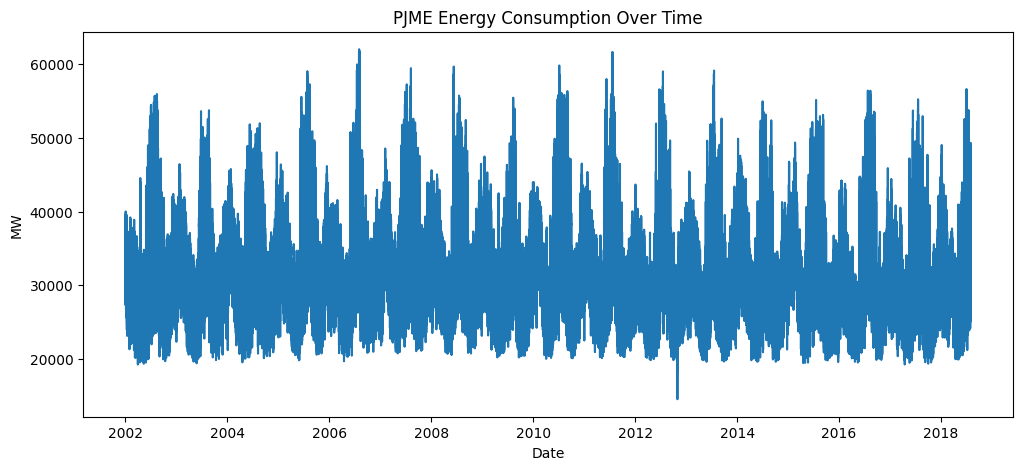

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Use df.index to access the Datetime index directly
plt.plot(df.index, df['PJME_MW']) 

plt.title('PJME Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()


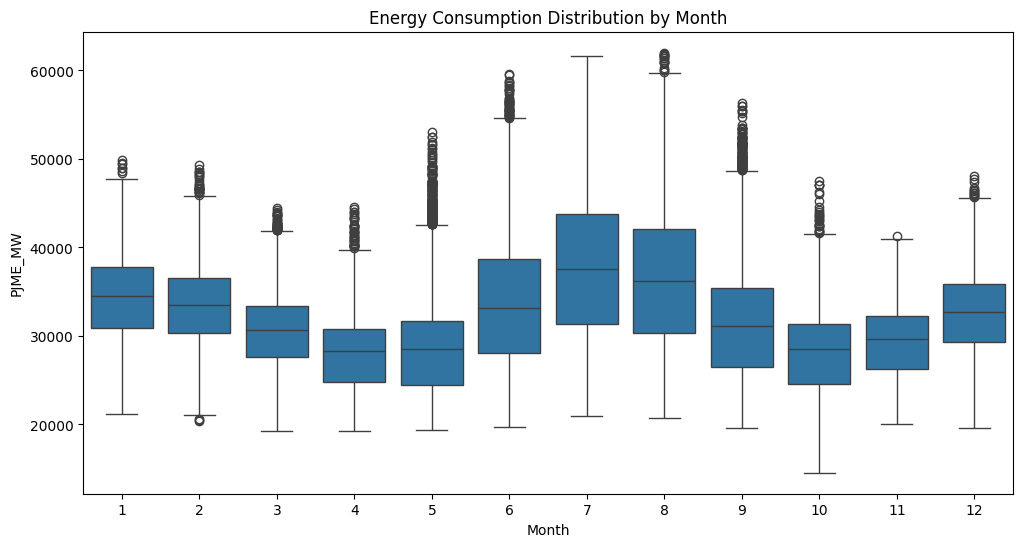

In [5]:
import seaborn as sns

# Create helper columns from the index
df['Year'] = df.index.year
df['Month'] = df.index.month

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Month', y='PJME_MW')
plt.title('Energy Consumption Distribution by Month')
plt.show()


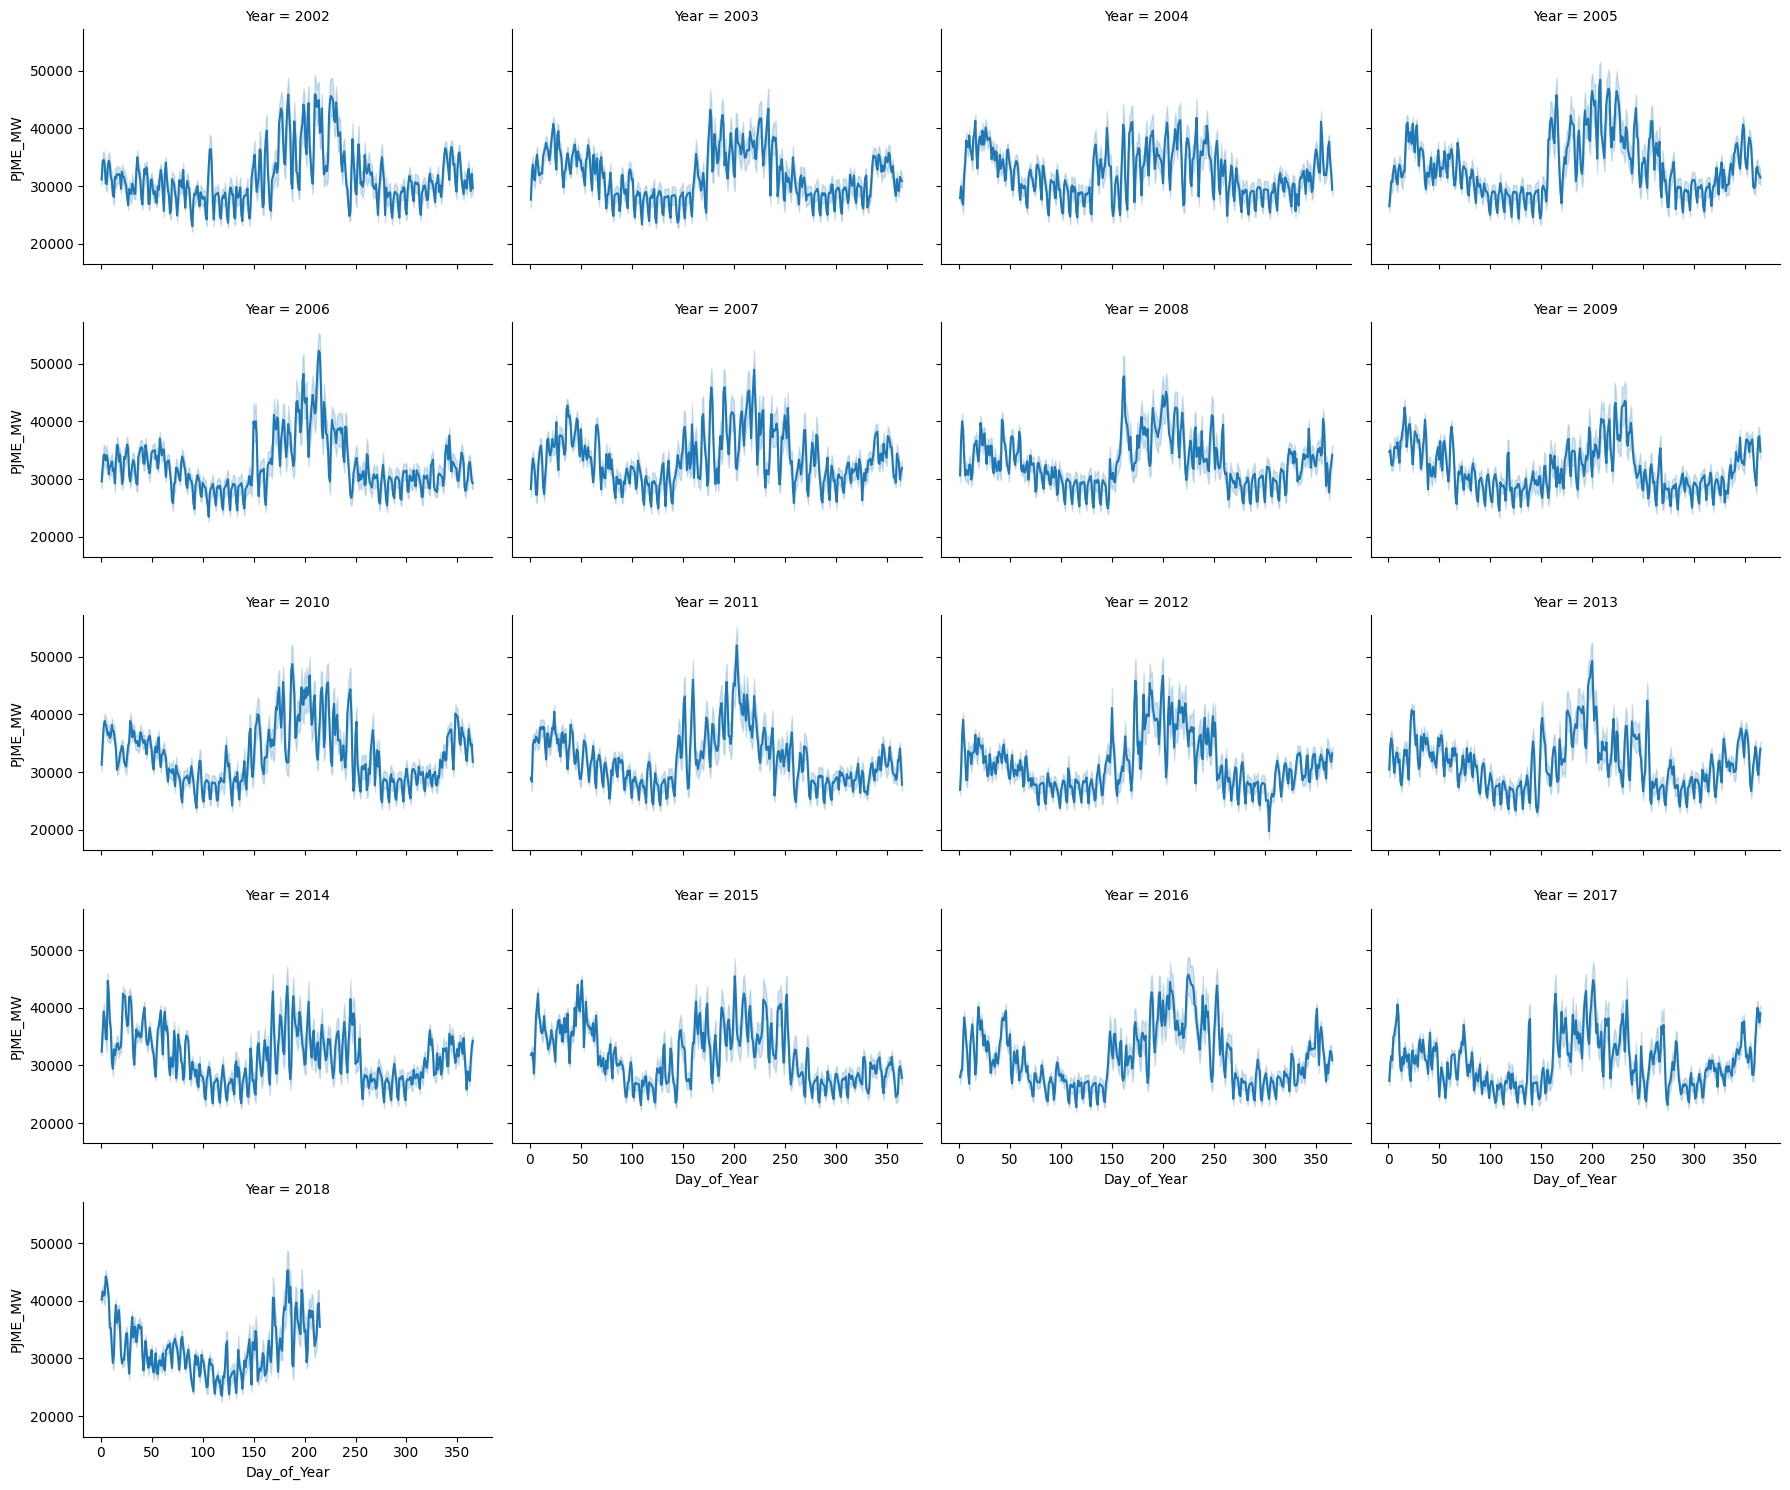

In [6]:
df['Day_of_Year'] = df.index.dayofyear
sns.relplot(
    data=df, 
    x='Day_of_Year', 
    y='PJME_MW', 
    col='Year',      # Create a new subplot for every year
    col_wrap=4,      # 4 charts per row
    kind='line', 
    height=3, 
    aspect=1.5
)


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PJME_MW      145366 non-null  float64
 1   Year         145366 non-null  int32  
 2   Month        145366 non-null  int32  
 3   Day_of_Year  145366 non-null  int32  
dtypes: float64(1), int32(3)
memory usage: 7.9 MB
None
             PJME_MW           Year          Month    Day_of_Year
count  145366.000000  145366.000000  145366.000000  145366.000000
mean    32080.222831    2009.801026       6.435948     180.459378
std      6464.012166       4.791823       3.438946     105.137240
min     14544.000000    2002.000000       1.000000       1.000000
25%     27573.000000    2006.000000       3.000000      90.000000
50%     31421.000000    2010.000000       6.000000     179.000000
75%     35650.000000    2014.000000       9.000000     271.000000
max     62009.0

In [8]:
df.head()

,PJME_MW,Year,Month,Day_of_Year
Datetime,,,,
2002-01-01 01:00:00,30393.0,2002,1,1
2002-01-01 02:00:00,29265.0,2002,1,1
2002-01-01 03:00:00,28357.0,2002,1,1
2002-01-01 04:00:00,27899.0,2002,1,1
2002-01-01 05:00:00,28057.0,2002,1,1


In [9]:
expected = pd.date_range(df.index.min(), df.index.max(), freq="H")
missing = expected.difference(df.index)

print("Missing timestamps:", len(missing))

Missing timestamps: 30


/tmp/ipykernel_42005/622172779.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected = pd.date_range(df.index.min(), df.index.max(), freq="H")


In [10]:
df.isnull().sum()

PJME_MW        0
Year           0
Month          0
Day_of_Year    0
dtype: int64

In [11]:
df.index.duplicated().sum()

np.int64(4)

In [12]:
df = df[~df.index.duplicated()]

In [13]:
from scipy.stats import zscore

df["zscore"] = zscore(df["PJME_MW"])

outliers = df[df["zscore"].abs() > 4]
print(len(outliers))

93


In [14]:
df.head()

,PJME_MW,Year,Month,Day_of_Year,zscore
Datetime,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,-0.261069
2002-01-01 02:00:00,29265.0,2002,1,1,-0.435578
2002-01-01 03:00:00,28357.0,2002,1,1,-0.576052
2002-01-01 04:00:00,27899.0,2002,1,1,-0.646908
2002-01-01 05:00:00,28057.0,2002,1,1,-0.622464


In [15]:
daily_df = df.resample('D')['PJME_MW'].agg(
    daily_total_load='sum',
    daily_mean_load='mean',
    daily_peak_load='max',
    daily_min_load='min',
    daily_std='std'
).reset_index()

daily_df.rename(columns={'Datetime': 'date'}, inplace=True)
daily_df['month'] = daily_df['date'].dt.month
daily_df['day_of_year'] = daily_df['date'].dt.dayofyear
daily_df['weekday'] = daily_df['date'].dt.weekday

daily_df = daily_df[[
    'date', 'daily_total_load', 'daily_mean_load', 
    'daily_peak_load', 'daily_min_load', 'daily_std', 
    'month', 'day_of_year', 'weekday'
]]

numeric_cols = daily_df.select_dtypes(include=['number']).columns

daily_df[numeric_cols] = daily_df[numeric_cols].round(0).fillna(0).astype(int)

print(daily_df.head())

        date  daily_total_load  daily_mean_load  daily_peak_load  \
0 2002-01-01            714857            31081            35732   
1 2002-01-02            822277            34262            40002   
2 2002-01-03            828285            34512            39662   
3 2002-01-04            809171            33715            38263   
4 2002-01-05            729723            30405            34092   

   daily_min_load  daily_std  month  day_of_year  weekday  
0           27899       2458      1            1        1  
1           27301       4186      1            2        2  
2           28106       3798      1            3        3  
3           28122       3311      1            4        4  
4           26669       2308      1            5        5  


In [16]:
# Saving the daily_df pandas dataframe as a parquet file

daily_df.to_parquet('../data/processed/daily_load.parquet')